# RE-T1 — Day 7: Feature Extraction & Energy Clustering

**Task date:** 11 October 2026  
**Scope:** Frequency-domain feature extraction and energy clustering.

This notebook uses synthetic, locally generated signals only. It is a learning demonstration, not a validated RF classifier or analysis of real operational data.

## Learning objectives
- Estimate dominant frequency using FFT.
- Calculate relative spectral-energy measures in frequency bands.
- Combine measurements into feature vectors.
- Scale features and group them with KMeans.

**Simple Hinglish:** Feature signal ki useful numerical information hai. Feature vector ek signal ke features ki list hai. Clustering similar feature patterns ko groups mein rakhti hai.


## 1. Imports and configuration

If needed, install packages in a separate cell using `%pip install numpy matplotlib scikit-learn`.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)
FS = 1000
DURATION = 1.0
T = np.arange(0, DURATION, 1 / FS)

print("Sampling frequency:", FS, "Hz")
print("Number of samples:", len(T))
print("Duration:", DURATION, "seconds")


Sampling frequency: 1000 Hz
Number of samples: 1000
Duration: 1.0 seconds


## 2. Generate synthetic signals

We create clean sine waves at 50, 55, 150, and 155 Hz. These are artificial learning examples, not real-world measurements.


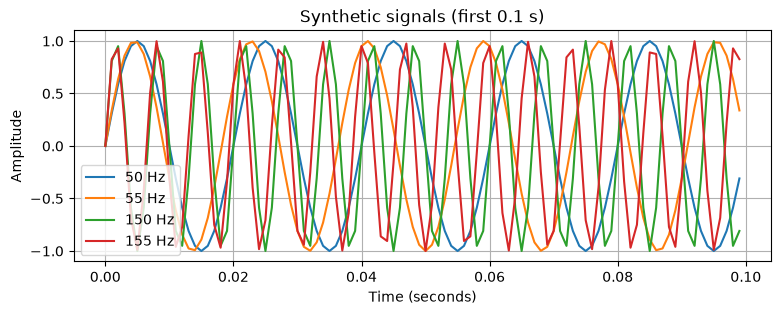

In [3]:
signal_frequencies = [50, 55, 150, 155]
signals = [np.sin(2 * np.pi * f * T) for f in signal_frequencies]

samples_to_plot = int(0.1 * FS)
plt.figure(figsize=(9, 3))
for f, signal in zip(signal_frequencies, signals):
    plt.plot(T[:samples_to_plot], signal[:samples_to_plot], label=f"{f} Hz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Synthetic signals (first 0.1 s)")
plt.legend()
plt.grid(True)
plt.show()


## 3. Extract frequency-domain features

For each signal we calculate:
- Dominant frequency: largest non-DC FFT magnitude.
- Low-band measure: sum of squared FFT magnitudes from 0 to below 100 Hz.
- High-band measure: sum of squared FFT magnitudes from 100 to below 200 Hz.

**Important:** These are relative spectral-energy measures, not calibrated physical energy or power spectral density. FFT normalization and window choices matter for physical interpretation.


In [4]:
def extract_features(signal, fs):
    fft_values = np.fft.rfft(signal)
    frequencies = np.fft.rfftfreq(len(signal), d=1 / fs)
    magnitude = np.abs(fft_values)
    squared_magnitude = magnitude ** 2

    # Ignore the DC bin when selecting the dominant frequency
    dominant_index = np.argmax(magnitude[1:]) + 1
    dominant_frequency = frequencies[dominant_index]

    low_mask = (frequencies >= 0) & (frequencies < 100)
    high_mask = (frequencies >= 100) & (frequencies < 200)

    low_measure = np.sum(squared_magnitude[low_mask])
    high_measure = np.sum(squared_magnitude[high_mask])

    return {
        "dominant_frequency_hz": float(dominant_frequency),
        "low_band_measure": float(low_measure),
        "high_band_measure": float(high_measure),
        "frequencies": frequencies,
        "magnitude": magnitude,
    }

results = [extract_features(signal, FS) for signal in signals]

for f, r in zip(signal_frequencies, results):
    print(f"Input {f:>3} Hz | Dominant {r['dominant_frequency_hz']:>6.1f} Hz | "
          f"Low-band measure {r['low_band_measure']:.1f} | "
          f"High-band measure {r['high_band_measure']:.1f}")


Input  50 Hz | Dominant   50.0 Hz | Low-band measure 250000.0 | High-band measure 0.0
Input  55 Hz | Dominant   55.0 Hz | Low-band measure 250000.0 | High-band measure 0.0
Input 150 Hz | Dominant  150.0 Hz | Low-band measure 0.0 | High-band measure 250000.0
Input 155 Hz | Dominant  155.0 Hz | Low-band measure 0.0 | High-band measure 250000.0


## 4. Visualize the spectrum and frequency resolution

Frequency-bin spacing is \(\Delta f = f_s/N\). Here, 1000 Hz sampling and 1000 samples gives 1 Hz spacing.


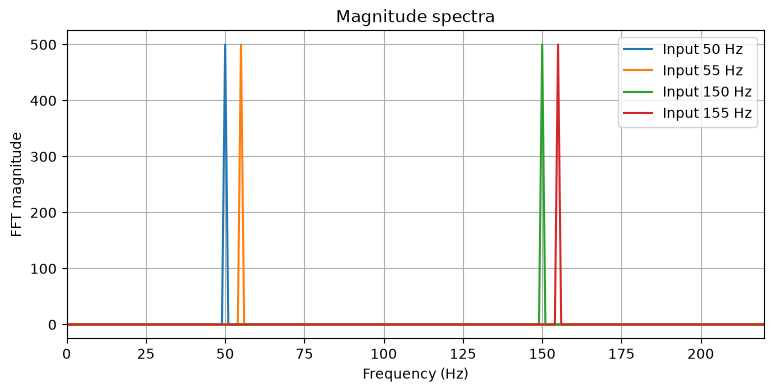

Frequency-bin spacing: 1.0 Hz


In [5]:
plt.figure(figsize=(9, 4))
for f, r in zip(signal_frequencies, results):
    plt.plot(r["frequencies"], r["magnitude"], label=f"Input {f} Hz")
plt.xlim(0, 220)
plt.xlabel("Frequency (Hz)")
plt.ylabel("FFT magnitude")
plt.title("Magnitude spectra")
plt.legend()
plt.grid(True)
plt.show()

print("Frequency-bin spacing:", FS / len(T), "Hz")


## 5. Build feature vectors

Each row represents one signal. Columns are dominant frequency, low-band measure, and high-band measure.


In [6]:
feature_names = [
    "dominant_frequency_hz",
    "low_band_measure",
    "high_band_measure"
]

feature_matrix = np.array([
    [r["dominant_frequency_hz"], r["low_band_measure"], r["high_band_measure"]]
    for r in results
], dtype=float)

print("Feature names:", feature_names)
print("Feature matrix (one row per signal):")
print(feature_matrix)


Feature names: ['dominant_frequency_hz', 'low_band_measure', 'high_band_measure']
Feature matrix (one row per signal):
[[    50. 250000.      0.]
 [    55. 250000.      0.]
 [   150.      0. 250000.]
 [   155.      0. 250000.]]


## 6. Scale the features

The features have different numerical scales. StandardScaler standardizes each column to mean approximately 0 and standard deviation approximately 1 when that column varies.

For real model evaluation, fit the scaler on training data only and apply it to held-out data. Here, the full tiny dataset is used only for demonstration.


In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_matrix)
print("Scaled feature matrix:")
print(np.round(scaled_features, 3))


Scaled feature matrix:
[[-1.049  1.    -1.   ]
 [-0.949  1.    -1.   ]
 [ 0.949 -1.     1.   ]
 [ 1.049 -1.     1.   ]]


## 7. KMeans energy-feature clustering

We request two clusters. Cluster IDs (0 and 1) are arbitrary labels; they do not automatically mean “low” or “high” frequency.


In [8]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_features)

for f, label in zip(signal_frequencies, cluster_labels):
    print(f"Signal with input tone {f:>3} Hz -> Cluster {label}")


Signal with input tone  50 Hz -> Cluster 0
Signal with input tone  55 Hz -> Cluster 0
Signal with input tone 150 Hz -> Cluster 1
Signal with input tone 155 Hz -> Cluster 1


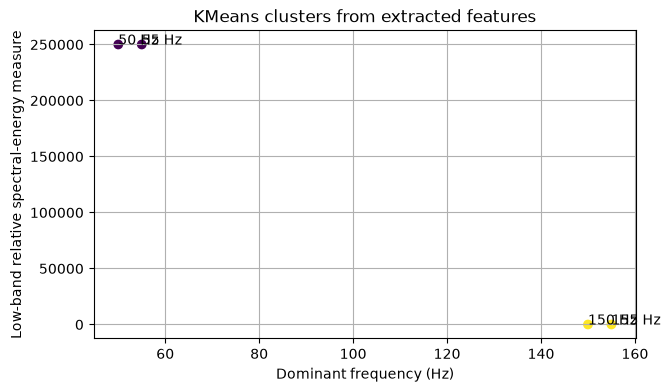

In [9]:
plt.figure(figsize=(7, 4))
plt.scatter(feature_matrix[:, 0], feature_matrix[:, 1], c=cluster_labels)
for i, f in enumerate(signal_frequencies):
    plt.annotate(f"{f} Hz", (feature_matrix[i, 0], feature_matrix[i, 1]))
plt.xlabel("Dominant frequency (Hz)")
plt.ylabel("Low-band relative spectral-energy measure")
plt.title("KMeans clusters from extracted features")
plt.grid(True)
plt.show()


## 8. Interpretation and limitations

### What this demonstrates
- FFT can identify the dominant frequency of these clean sine waves.
- Band-wise squared-magnitude sums summarize spectral content in selected frequency ranges.
- A feature vector stores several numerical measurements for each signal.
- Scaling can stop large numerical scales from dominating distance-based clustering.
- KMeans groups feature vectors; cluster labels are not classifications by themselves.

### Limitations
- The signals are synthetic, clean, and simple.
- Band measures are not calibrated physical energy or PSD.
- Two clusters are selected for demonstration; the best cluster count is not established.
- Real data may require windowing, noise handling, validation, and domain-specific features.
- This small example does not establish real-world signal source or class.

## 9. Quick review
1. **Dominant frequency:** strongest non-DC FFT magnitude in this example.
2. **Frequency bin:** a discrete point in the FFT frequency representation.
3. **Band-energy measure:** summarizes spectral content within a selected frequency range.
4. **Feature vector:** numerical feature list for one signal.
5. **Scaling:** makes feature scales more comparable for distance calculations.
6. **Cluster IDs:** arbitrary labels assigned by the algorithm.
